In [28]:
import pandas as pd
import numpy as np
from numpy import array
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
%matplotlib inline

In [29]:
df=pd.read_csv('apple_share_price.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,11-Aug-17,156.60,158.57,156.07,157.48,26257096
1,10-Aug-17,159.90,160.00,154.63,155.32,40804273
2,9-Aug-17,159.26,161.27,159.11,161.06,26131530
3,8-Aug-17,158.60,161.83,158.27,160.08,36205896
4,7-Aug-17,157.06,158.92,156.67,158.81,21870321


In [30]:
df.isna().sum()
df.shape

(1664, 6)

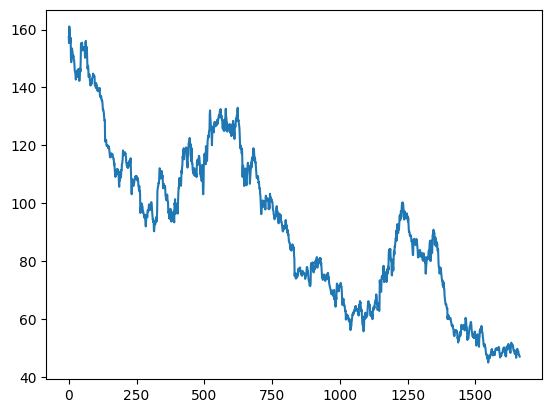

In [31]:
df1=df.reset_index()['Close'];df1
plt.plot(df1)

In [32]:
# Normalize the data to ensure that all features have the same scale. This is important for the LSTM to learn effectively.

scaler = MinMaxScaler(feature_range=(0, 1))
df['Close'] = scaler.fit_transform(np.array(df['Close']).reshape(-1, 1))

Create Sequences for LSTM
Create input sequences for the LSTM model. This involves defining a window of past data that the model will use for prediction.

In [33]:
def create_sequences(data,seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        seq = data[i:i+seq_length]
        sequences.append(seq)
    return np.array(sequences)

seq_length = 10  # Adjust as needed
X = create_sequences(df['Close'], seq_length)

In [34]:
# Split Data into Training and Testing Sets:¶

train_size = int(len(X) * 0.8)
test_size = len(X) - train_size
train, test = X[0:train_size], X[train_size:len(X)]

In [35]:
from tensorflow.keras.layers import Dropout

model = Sequential()

# Add the first LSTM layer with return_sequences=True
model.add(LSTM(units=100, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))  # Add dropout for regularization

# Add a second LSTM layer with return_sequences=True
model.add(LSTM(units=100, return_sequences=True))
model.add(Dropout(0.2))

# Add a third LSTM layer with return_sequences=True
model.add(LSTM(units=100, return_sequences=True))
model.add(Dropout(0.2))

# Add a fourth LSTM layer without return_sequences (default is False)
model.add(LSTM(units=100))
model.add(Dropout(0.2))

# Add a Dense layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
# LSTM Model Architecture
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='lstm_model.png', show_shapes=True, show_layer_names=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [37]:
target_data = df['Close'][seq_length:seq_length+train_size]
historyy = model.fit(train, target_data, epochs=10, batch_size=32,validation_split=0.2)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - loss: 0.1103 - val_loss: 0.0067
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0064 - val_loss: 0.0018
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0034 - val_loss: 0.0011
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0037 - val_loss: 0.0016
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0038 - val_loss: 0.0011
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0038 - val_loss: 0.0010
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0027 - val_loss: 0.0013
Epoch 9/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0035 - val_loss: 0.0011
Epoch 10/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0024 - val_loss: 0.0011


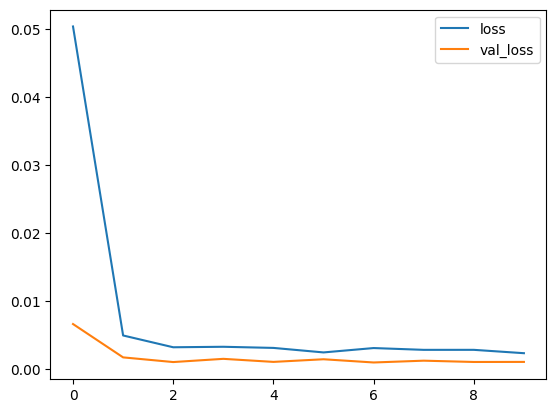

In [38]:
history_df = pd.DataFrame(historyy.history)
history_df.loc[:, ['loss', 'val_loss']].plot();

In [39]:
# Make Predictions
predictions = model.predict(test)
predictions = scaler.inverse_transform(predictions)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step


Plot Results

/tmp/ipykernel_20833/522608240.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = predictions


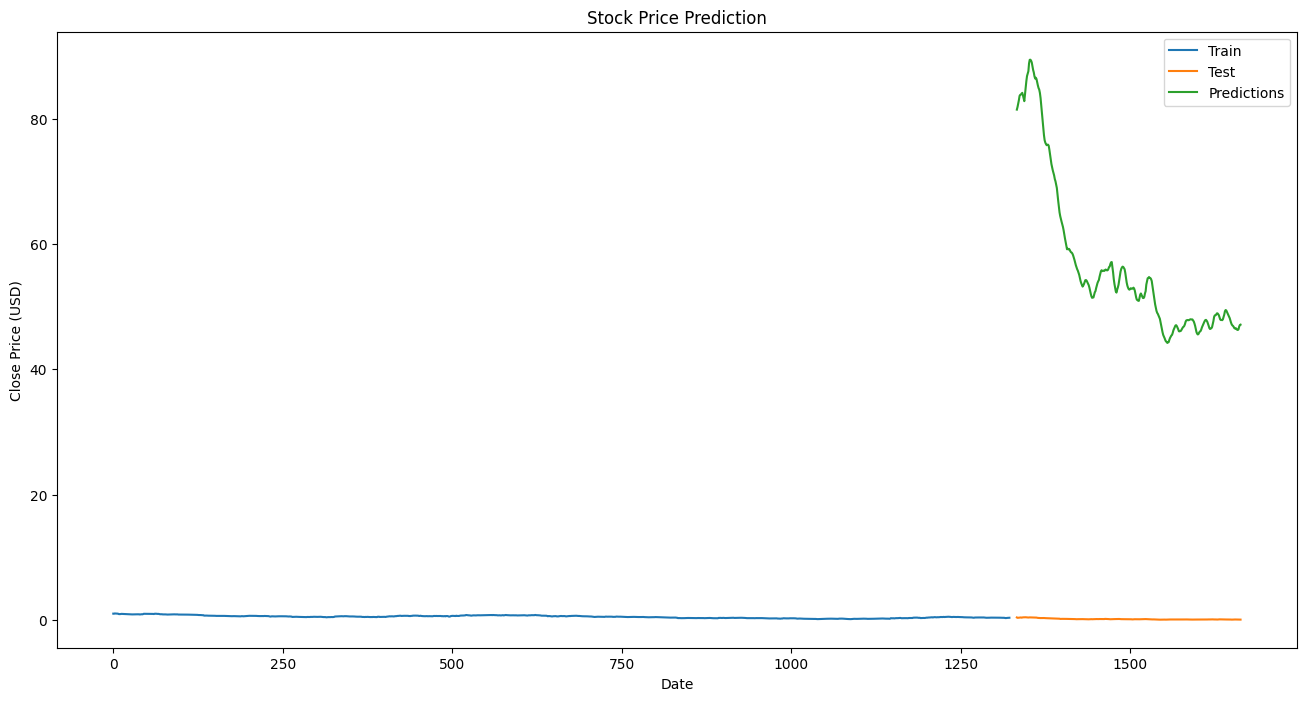

In [40]:
train = df.iloc[:train_size, :]
test = df.iloc[train_size+seq_length:, :]

test['Predictions'] = predictions
plt.figure(figsize=(16,8))
plt.title('Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.plot(train['Close'])
plt.plot(test[['Close', 'Predictions']])
plt.legend(['Train', 'Test', 'Predictions'])
plt.show()

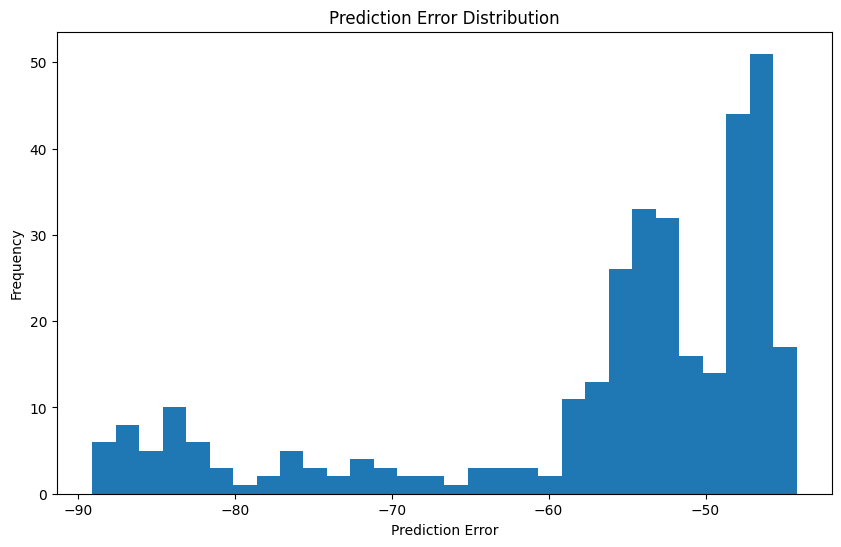

In [41]:
#Prediction Error Distribution
error = test['Close'] - test['Predictions']
plt.figure(figsize=(10,6))
plt.hist(error, bins=30)
plt.title('Prediction Error Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.show()

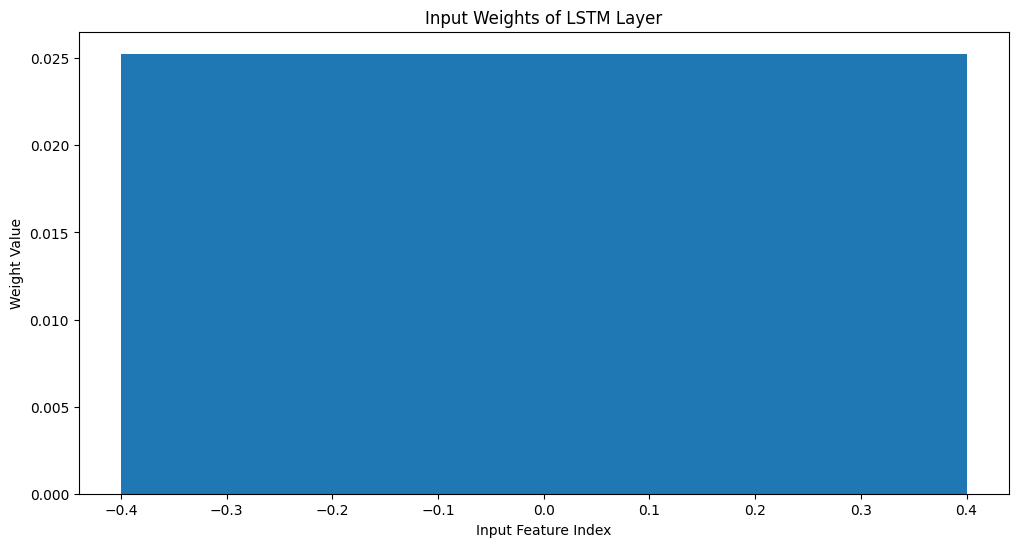

In [42]:
# Feature Importance (Input Weights)
weights = model.layers[0].get_weights()[0]
plt.figure(figsize=(12,6))
plt.bar(range(len(weights)), weights[:, 0])
plt.title('Input Weights of LSTM Layer')
plt.xlabel('Input Feature Index')
plt.ylabel('Weight Value')
plt.show()

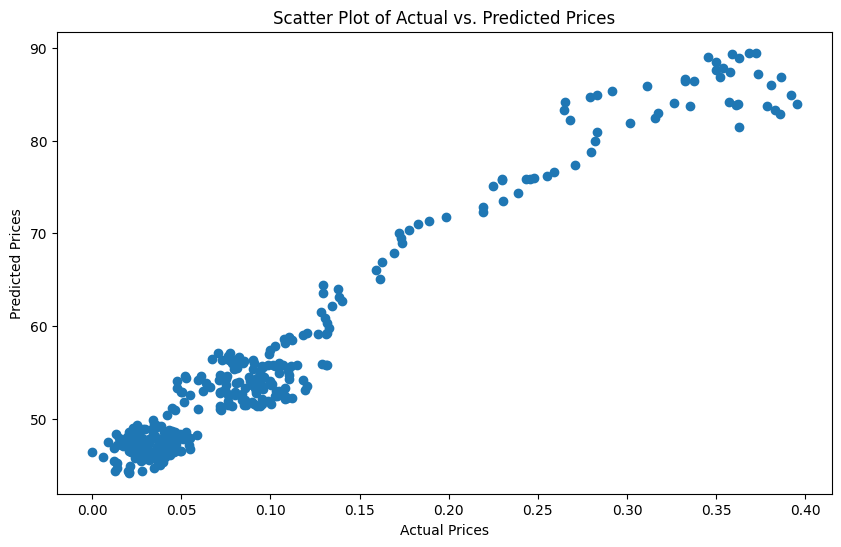

In [43]:
#Scatter Plot of Actual vs. Predicted Prices
plt.figure(figsize=(10,6))
plt.scatter(test['Close'], test['Predictions'])
plt.title('Scatter Plot of Actual vs. Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

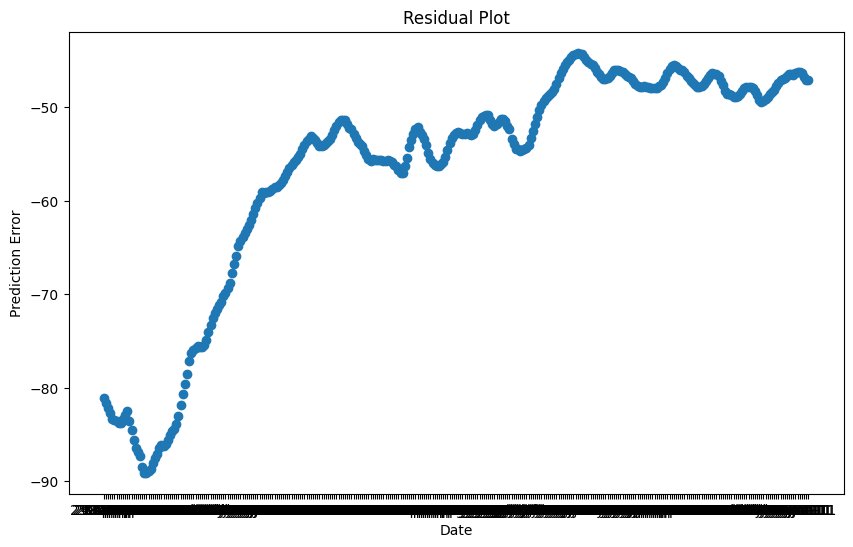

In [44]:
# Residual Plot
plt.figure(figsize=(10,6))
plt.scatter(test['Date'], error)
plt.title('Residual Plot')
plt.xlabel('Date')
plt.ylabel('Prediction Error')
plt.show()

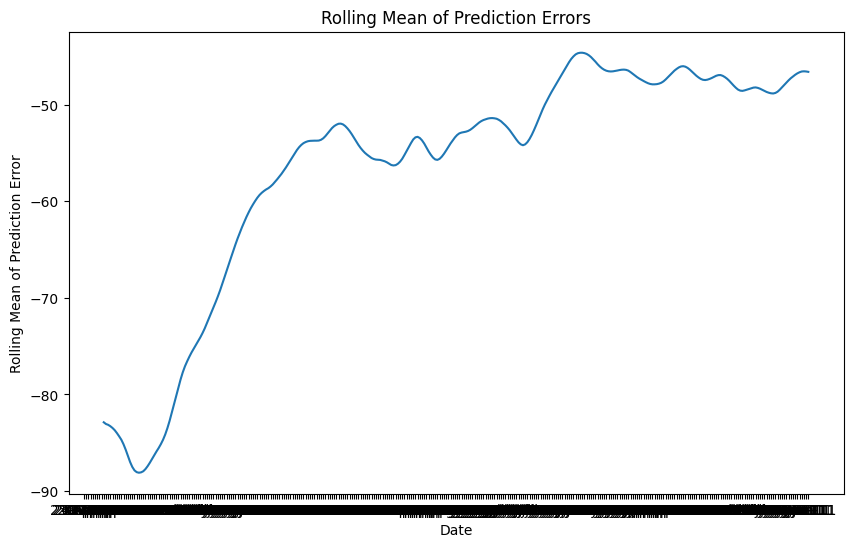

In [45]:
# Rolling Mean of Prediction Errors
rolling_mean = error.rolling(window=10).mean()
plt.figure(figsize=(10,6))
plt.plot(test['Date'], rolling_mean)
plt.title('Rolling Mean of Prediction Errors')
plt.xlabel('Date')
plt.ylabel('Rolling Mean of Prediction Error')
plt.show()

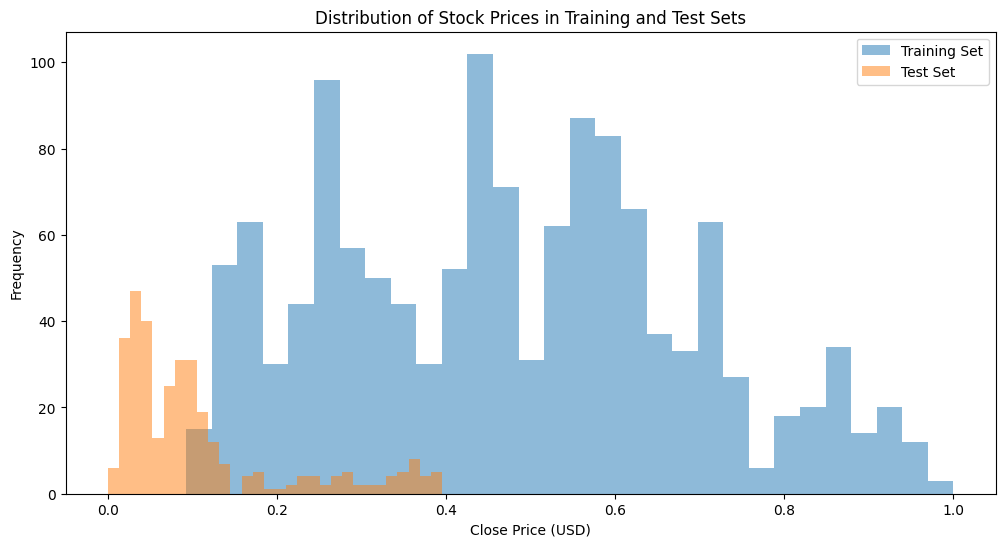

In [46]:
# Distribution of Training and Test Sets
plt.figure(figsize=(12,6))
plt.hist(train['Close'], bins=30, alpha=0.5, label='Training Set')
plt.hist(test['Close'], bins=30, alpha=0.5, label='Test Set')
plt.title('Distribution of Stock Prices in Training and Test Sets')
plt.xlabel('Close Price (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.show()